## Project 3 


### 3.1 Stationary Advection Diffusion problem


In [1]:
# load all necessary libraries
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# define the exact solution
def exact_u(x, epsilon):
    return x - (np.exp(x/epsilon) - 1) / (np.exp(1/epsilon) - 1)
def exact_u_derivative(x, epsilon):
    return 1 - np.exp(x/epsilon) / (epsilon*(np.exp(1/epsilon) - 1))

In [3]:
# define FEM
def initialize_FEM(km, h, epsilon):
    A = epsilon/h * (np.diag([2] * km) + np.diag([-1] * (km - 1), k=1) + np.diag([-1] * (km - 1), k=-1))
    A += 1/2 * (np.diag([1] * (km - 1), k=1) + np.diag([-1] * (km - 1), k=-1))
    b = h * np.ones(km)  
    return A, b 

In [14]:
# create function to plot results 
def plot_results(x_nodes, U, epsilon, h):
    x_eval = np.linspace(0,1,1000) # make a better grid for exact solution
    exact_values = np.array([exact_u(x, epsilon) for x in x_eval])
    plt.plot(x_eval, exact_values, color = 'olivedrab', label='exact')
    plt.plot(x_nodes, U, marker = 'o', color = 'darkorchid', label='numerical')
    plt.legend()
    plt.xlabel('x')
    plt.title(f'$\epsilon$ ={epsilon}, h={h}')
    plt.savefig(f'plot_epsilon{epsilon}_h{h}.png')
    plt.show()

#### Error calculation

In [15]:
# calculate errors
def compute_errors(x_nodes, U_full, epsilon, h):
    def u_h(x):
        return np.interp(x, x_nodes, U_full)
    def u_h_derivative(x):
        idx = int(np.floor(x/h))
        idx = min(idx, len(U_full) - 2)  # Ensure idx is within bounds
        return (U_full[idx+1] - U_full[idx]) / h
    
    x_lines = np.linspace(0, 1, 1000)

    u_h_values = np.array([u_h(x) for x in x_lines])
    u_h_derivative_values = np.array([u_h_derivative(x) for x in x_lines])
    u_exact_values = np.array([exact_u(x, epsilon) for x in x_lines])
    u_exact_derivative_values = np.array([exact_u_derivative(x, epsilon) for x in x_lines])

    L2_error = np.trapz((u_h_values - u_exact_values)**2, x_lines)
    L2_error_derivative = np.trapz((u_h_derivative_values - u_exact_derivative_values)**2, x_lines)

    L2_error = np.sqrt(L2_error)
    L2_error_derivative = np.sqrt(L2_error_derivative)
        
    return L2_error, L2_error_derivative

#### plots for different $\epsilon$ and h

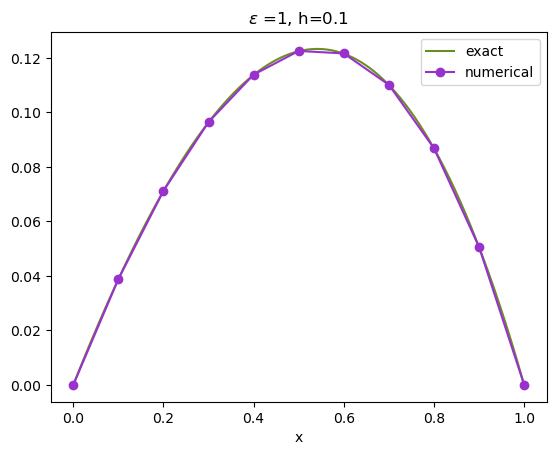

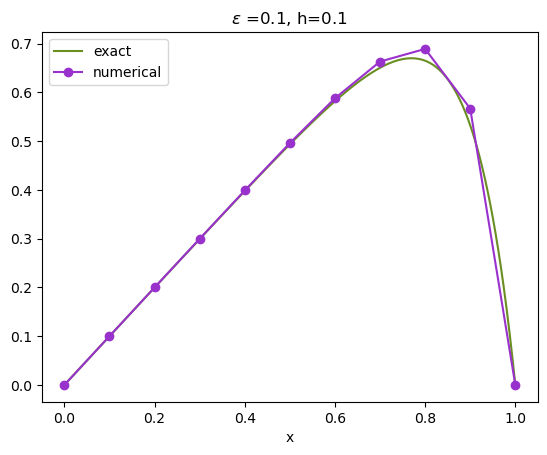

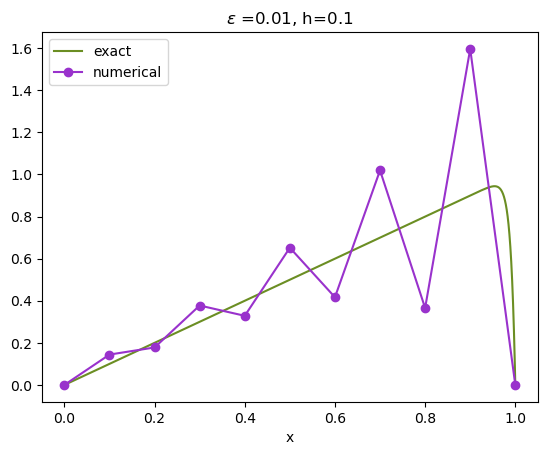

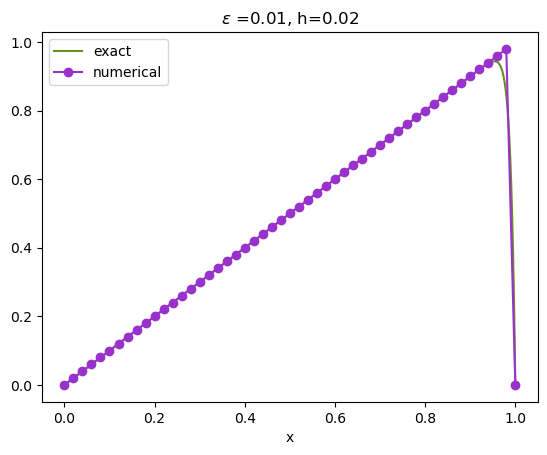

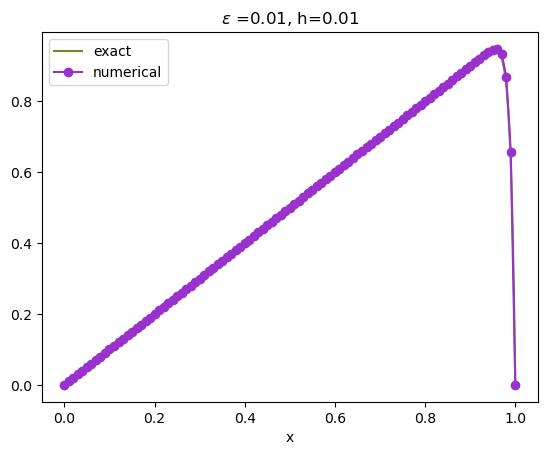

$\epsilon$=1, h=0.1, L2 error=8.92e-04, L2 error derivative=3.00e-02
$\epsilon$=0.1, h=0.1, L2 error=1.51e-02, L2 error derivative=6.25e-01
$\epsilon$=0.01, h=0.1, L2 error=1.91e-01, L2 error derivative=8.24e+00
$\epsilon$=0.01, h=0.02, L2 error=1.77e-02, L2 error derivative=3.62e+00
$\epsilon$=0.01, h=0.01, L2 error=4.82e-03, L2 error derivative=1.92e+00


In [16]:
# create function for varying values
iter = [(1, 0.1), (0.1, 0.1), (0.01, 0.1), (0.01, 0.02), (0.01, 0.01)]
L2_errors = []
L2_errors_derivative = []

for epsilon, h in iter:
    km = int(1/h) - 1
    A, b = initialize_FEM(km, h, epsilon)
    U = np.linalg.solve(A, b)
    # add boundary conditions to U
    U_full = np.concatenate(([0], U, [0]))
    x_nodes = np.arange(0, 1 + h, h)
    plot_results(x_nodes, U_full, epsilon, h)

    # call function for errors
    L2_error, L2_error_derivative = compute_errors(x_nodes, U_full, epsilon, h)
    L2_errors.append(L2_error)
    L2_errors_derivative.append(L2_error_derivative)


for i, (epsilon, h) in enumerate(iter):
    print(f'$\epsilon$={epsilon}, h={h}, L2 error={L2_errors[i]:.2e}, L2 error derivative={L2_errors_derivative[i]:.2e}')

### 3.2 Parabolic Equation

In [19]:
# define initial condition
def u_0(x):
    return x*(x-1)

In [20]:
# define constant variables
h = 0.1
dt = 0.1
T = 1
km = int(1/h) - 1
N = int(T/dt)
# define matrices
C = h/6 * (np.diag([4] * km) + np.diag([1] * (km - 1), k=1) + np.diag([-1] * (km - 1), k=-1))
D = 1/h * (np.diag([2] * km) + np.diag([-1] * (km - 1), k=1) + np.diag([-1] * (km - 1), k=-1))
x_nodes = np.arange(0, 1 + h, h)
U_zero = u_0(x_nodes[1:-1])

In [21]:
# implement method
def solve_PE(epsilon, h, N, dt, C, D, U_zero):
    LHS = (1 - dt/2)*C + epsilon*dt/2*D
    RHS = (1 + dt/2)*C - epsilon*dt/2*D

    U = U_zero

    for n in range(N):
        U_new = np.linalg.solve(LHS, RHS @ U)
        U = U_new
    return U

In [22]:
# generate function to plot results
def plot_results_1(x_nodes, U, epsilon, h):
    U_full = np.concatenate(([0], U, [0]))
    x_eval = np.linspace(0,1,1000)
    exact_values = np.array([u_0(x) for x in x_eval])
    plt.plot(x_eval, exact_values, color = 'olivedrab', label='exact')
    plt.plot(x_nodes, U_full, marker = 'o', color = 'darkorchid', label='numerical')
    plt.legend()
    plt.xlabel('x')
    plt.title(f'$\epsilon$ ={epsilon}, h={h}')
    plt.savefig(f'plot2_epsilon{epsilon}_h{h}.png')
    plt.show()

#### $\epsilon = $ 1

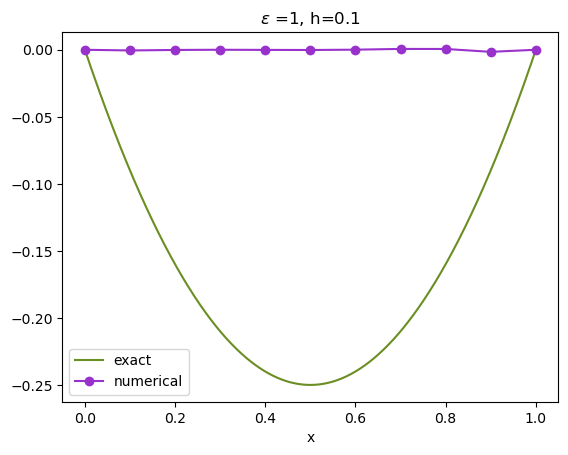

In [23]:
epsilon = 1
U = solve_PE(epsilon, h, N, dt, C, D, U_zero)
plot_results_1(x_nodes, U, epsilon, h)

 $\epsilon = 10^{-3}$

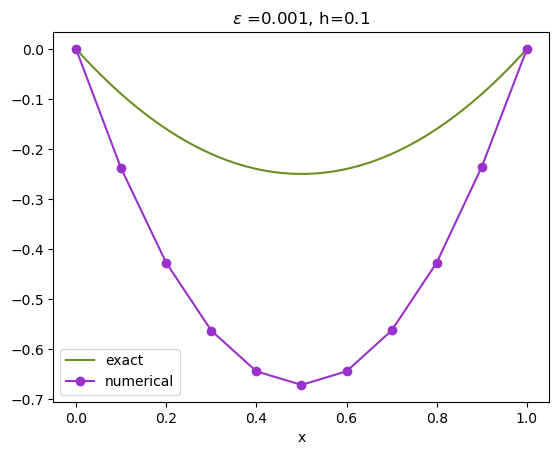

In [24]:
epsilon = 1e-3
U = solve_PE(epsilon, h, N, dt, C, D, U_zero)
plot_results_1(x_nodes, U, epsilon, h)

$\epsilon = 0.1, 10^{-2}, 10^{-6}$

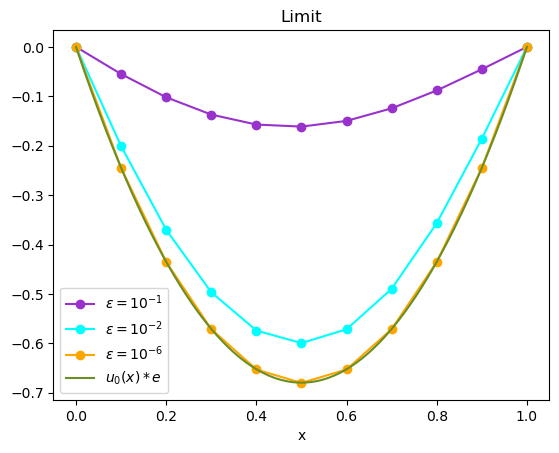

In [31]:

epsilon = 1e-1
U1 = solve_PE(epsilon, h, N, dt, C, D, U_zero)

epsilon = 1e-2
U2 = solve_PE(epsilon, h, N, dt, C, D, U_zero)

epsilon = 1e-6
U3 = solve_PE(epsilon, h, N, dt, C, D, U_zero)

U_full_1 = np.concatenate(([0], U1, [0]))
U_full_2 = np.concatenate(([0], U2, [0]))
U_full_3 = np.concatenate(([0], U3, [0]))


x_eval = np.linspace(0,1,1000)
limit_solution = np.array([np.exp(1)*u_0(x) for x in x_eval])
plt.plot(x_nodes, U_full_1, marker = 'o', color = 'darkorchid', label='$\epsilon=10^{-1}$')
plt.plot(x_nodes, U_full_2, marker = 'o', color = 'cyan', label='$\epsilon=10^{-2}$')
plt.plot(x_nodes, U_full_3, marker = 'o', color = 'orange', label='$\epsilon=10^{-6}$')
plt.plot(x_eval, limit_solution, color = 'olivedrab', label='$u_0(x)*e$')
plt.legend()
plt.xlabel('x')
plt.title(f'Limit')
plt.savefig(f'plot_limit.png')
plt.show()